In [1]:
import torch
import numpy as np
import scipy
from datasets import load_dataset

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ GPU Active: {torch.cuda.get_device_name(0)}")
print(f"✅ NumPy: {np.__version__}")

try:
    lstm = torch.nn.LSTM(128, 256, batch_first=True, bidirectional=True).cuda()
    test_input = torch.randn(4, 10, 128).cuda()
    out, _ = lstm(test_input)
    print("✅ LSTM GPU Kernel: WORKING")
except Exception as e:
    print(f"❌ LSTM GPU Kernel: FAILED - {e}")

try:
    dataset = load_dataset("ag_news", split='train[:1%]')
    print("✅ Dataset Loading: WORKING")
except Exception as e:
    print(f"❌ Dataset Loading: FAILED - {e}")

✅ PyTorch: 2.10.0+cu128
✅ GPU Active: Tesla T4
✅ NumPy: 2.0.2
✅ LSTM GPU Kernel: WORKING


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

✅ Dataset Loading: WORKING


In [2]:
import torch

lstm = torch.nn.LSTM(128, 256, batch_first=True, bidirectional=True).cuda()
x = torch.randn(4, 10, 128).cuda()
out, _ = lstm(x)

if out.shape == (4, 10, 512):
    print("LSTM on GPU test: ✅ PASSED")
else:
    print(f"❌ FAILED: Unexpected shape {out.shape}")

LSTM on GPU test: ✅ PASSED


In [3]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords',                  quiet=True)
nltk.download('punkt',                      quiet=True)
nltk.download('punkt_tab',                  quiet=True)
nltk.download('wordnet',                    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.corpus   import stopwords
from nltk.stem     import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from datasets      import load_dataset

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [5]:
DATASET_NAME       = "ag_news"
LOW_RESOURCE_SIZES = [500, 1000, 5000]
TEST_SIZE          = 5000
USE_LEMMATIZER     = True    
REMOVE_STOPWORDS   = False  

In [6]:
LABEL_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

In [7]:
print("Loading 'ag_news' from Hugging Face …")
raw = load_dataset("ag_news")

print(raw)
print("\nExample record:", raw['train'][0])

Loading 'ag_news' from Hugging Face …
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Example record: {'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [8]:
train_df = pd.DataFrame(raw['train'])  
test_df  = pd.DataFrame(raw['test'])    

train_df['label_name'] = train_df['label'].map(LABEL_NAMES)
test_df['label_name']  = test_df['label'].map(LABEL_NAMES)

print(f"\nFull training set : {len(train_df):,} rows")
print(f"Full test set     : {len(test_df):,} rows")
print("\nLabel distribution (train):")
print(train_df['label_name'].value_counts())


Full training set : 120,000 rows
Full test set     : 7,600 rows

Label distribution (train):
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [9]:
def stratified_sample(df: pd.DataFrame, n: int, seed: int = SEED) -> pd.DataFrame:
    """Return n stratified rows from df, balanced across all labels."""
    n_classes    = df['label'].nunique()
    per_class    = n // n_classes
    return (
        df.groupby('label', group_keys=False)
          .apply(lambda g: g.sample(min(len(g), per_class), random_state=seed))
          .sample(frac=1, random_state=seed)
          .reset_index(drop=True)
    )

test_fixed = stratified_sample(test_df, TEST_SIZE)
print(f"\nFixed test set: {len(test_fixed)} samples")
print(test_fixed['label_name'].value_counts())


Fixed test set: 5000 samples
label_name
Sports      1250
Business    1250
World       1250
Sci/Tech    1250
Name: count, dtype: int64


/tmp/ipykernel_55/2209470229.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_class), random_state=seed))


In [10]:
low_resource_splits = {}

for n in LOW_RESOURCE_SIZES:
    subset = stratified_sample(train_df, n)
    low_resource_splits[n] = subset
    dist = subset['label_name'].value_counts().to_dict()
    print(f"  N={n:,}: {len(subset)} rows | {dist}")

print("\nAll low-resource splits created ✓")

  N=500: 500 rows | {'Business': 125, 'World': 125, 'Sports': 125, 'Sci/Tech': 125}
  N=1,000: 1000 rows | {'Business': 250, 'Sports': 250, 'Sci/Tech': 250, 'World': 250}
  N=5,000: 5000 rows | {'Sports': 1250, 'Business': 1250, 'World': 1250, 'Sci/Tech': 1250}

All low-resource splits created ✓


/tmp/ipykernel_55/2209470229.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_class), random_state=seed))
/tmp/ipykernel_55/2209470229.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_class), random_state=seed))
/tmp/ipykernel_55/2209470229.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

In [11]:
STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [12]:
def clean_text(text: str,
               remove_stopwords: bool = REMOVE_STOPWORDS,
               use_lemmatizer:   bool = USE_LEMMATIZER) -> str:
    """
    Cleaning steps:
      1. Remove URLs
      2. Remove non-ASCII / emojis
      3. Remove special characters (keep letters only)
      4. Lowercase
      5. Tokenize
      6. (Optional) Remove stopwords
      7. Lemmatize OR Stem
      8. Rejoin
    Note: No HTML removal needed — AG News has no HTML tags.
    """
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    text = text.encode('ascii', errors='ignore').decode('ascii')

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = text.lower()

    tokens = word_tokenize(text)

    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]

    if use_lemmatizer:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    else:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

In [13]:
print("\n── Cleaning Smoke Test ──────────────────────────────────")
for _, row in train_df.sample(3, random_state=SEED).iterrows():
    cleaned = clean_text(row['text'])
    print(f"\n  Category : {LABEL_NAMES[row['label']]}")
    print(f"  Original : {row['text']}")
    print(f"  Cleaned  : {cleaned}")


── Cleaning Smoke Test ──────────────────────────────────

  Category : Business
  Original : BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.
  Cleaned  : bbc set for major shake up claim newspaper london the british broadcasting corporation the world s biggest public broadcaster is to cut almost a quarter of it strong workforce in the biggest shake up in it year history the time newspaper in london said on monday

  Category : Business
  Original : Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh  amp; McLennan Cos.
  Cleaned  : marsh averts cash crunch embattled insurance broker s bank agree to waive clause that may have prevented access to c

In [14]:
print("\nCleaning test set …")
test_fixed['clean_text'] = test_fixed['text'].apply(clean_text)

print("Cleaning training subsets …")
for n, df in low_resource_splits.items():
    df['clean_text'] = df['text'].apply(clean_text)
    print(f"  N={n:,} done.")

print("\nAll splits cleaned ✓")


Cleaning test set …
Cleaning training subsets …
  N=500 done.
  N=1,000 done.
  N=5,000 done.

All splits cleaned ✓


In [15]:
def profile_split(df: pd.DataFrame, name: str):
    lengths = df['clean_text'].str.split().str.len()
    print(f"\n── {name} ──")
    print(f"  Samples     : {len(df):,}")
    print(f"  Avg tokens  : {lengths.mean():.1f}")
    print(f"  Median      : {lengths.median():.0f}")
    print(f"  Min / Max   : {lengths.min()} / {lengths.max()}")
    return lengths

In [16]:
print("\n=== Data Profile (cleaned text) ===")
profile_split(test_fixed, "Fixed Test Set (5k)")
for n, df in low_resource_splits.items():
    profile_split(df, f"Train N={n}")


=== Data Profile (cleaned text) ===

── Fixed Test Set (5k) ──
  Samples     : 5,000
  Avg tokens  : 38.0
  Median      : 37
  Min / Max   : 14 / 137

── Train N=500 ──
  Samples     : 500
  Avg tokens  : 38.4
  Median      : 37
  Min / Max   : 17 / 144

── Train N=1000 ──
  Samples     : 1,000
  Avg tokens  : 38.5
  Median      : 37
  Min / Max   : 16 / 144

── Train N=5000 ──
  Samples     : 5,000
  Avg tokens  : 38.2
  Median      : 37
  Min / Max   : 14 / 144


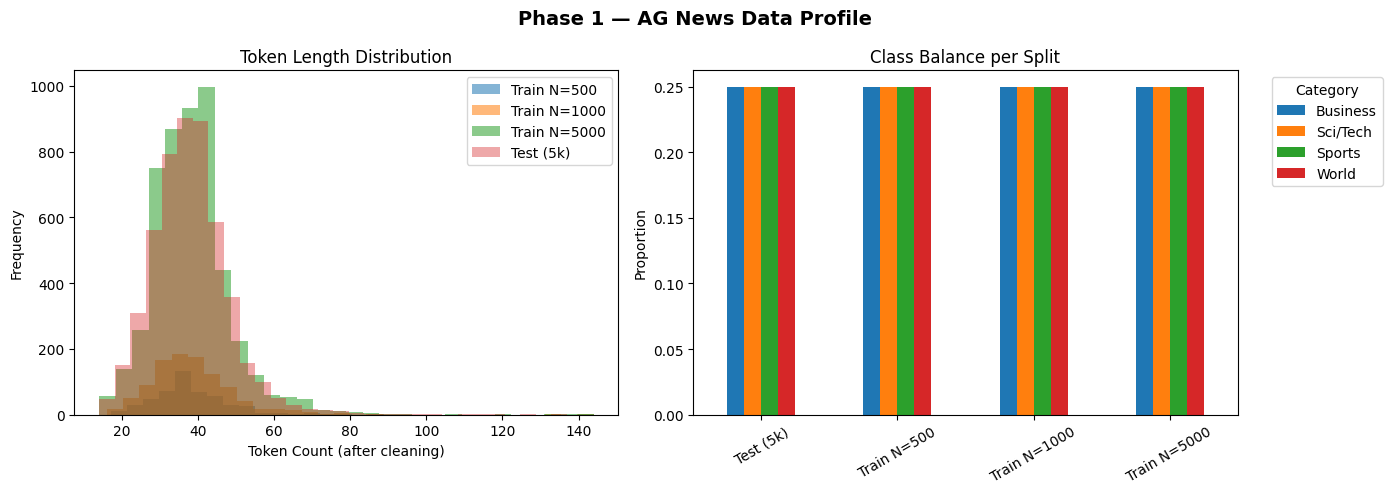

In [17]:
# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 1 — AG News Data Profile", fontsize=14, fontweight='bold')

ax = axes[0]
for n, df in low_resource_splits.items():
    lengths = df['clean_text'].str.split().str.len()
    ax.hist(lengths, bins=30, alpha=0.55, label=f"Train N={n}")
ax.hist(test_fixed['clean_text'].str.split().str.len(),
        bins=30, alpha=0.4, label="Test (5k)", linestyle='--')
ax.set_xlabel("Token Count (after cleaning)")
ax.set_ylabel("Frequency")
ax.set_title("Token Length Distribution")
ax.legend()

ax = axes[1]
split_labels = {'Test (5k)': test_fixed['label'].value_counts(normalize=True).rename(LABEL_NAMES)}
for n, df in low_resource_splits.items():
    split_labels[f'Train N={n}'] = df['label'].value_counts(normalize=True).rename(LABEL_NAMES)

label_df = pd.DataFrame(split_labels).T
label_df.plot(kind='bar', ax=ax, rot=30)
ax.set_title("Class Balance per Split")
ax.set_ylabel("Proportion")
ax.legend(title="Category", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig("phase1_agnews_profile.png", dpi=150)
plt.show()

In [18]:
test_fixed.to_csv("test_fixed_5000.csv", index=False)
print("\nSaved: test_fixed_5000.csv")

for n, df in low_resource_splits.items():
    fname = f"train_n{n}.csv"
    df.to_csv(fname, index=False)
    print(f"Saved: {fname}")


Saved: test_fixed_5000.csv
Saved: train_n500.csv
Saved: train_n1000.csv
Saved: train_n5000.csv


In [19]:
print("\n" + "="*55)
print("VERIFICATION CHECK")
print("="*55)

checks = {
    "Test set size == 5000"           : len(test_fixed) == TEST_SIZE,
    "Test set has 4 balanced classes" : test_fixed['label'].nunique() == 4,
    "N=500 split exists"              : 500  in low_resource_splits,
    "N=1000 split exists"             : 1000 in low_resource_splits,
    "N=5000 split exists"             : 5000 in low_resource_splits,
    "clean_text col in test set"      : 'clean_text' in test_fixed.columns,
    "No NaN in test clean_text"       : test_fixed['clean_text'].isna().sum() == 0,
    "No NaN in N=500 clean_text"      : low_resource_splits[500]['clean_text'].isna().sum() == 0,
    "Train/test splits are disjoint"  : len(
        set(test_fixed.index) & set(low_resource_splits[500].index)) == 0,
}


VERIFICATION CHECK


In [20]:
all_pass = True
for desc, result in checks.items():
    status = "✅ PASS" if result else "❌ FAIL"
    if not result: all_pass = False
    print(f"  {status}  {desc}")

print("="*55)
print("Phase 1 COMPLETE ✓" if all_pass else "⚠️  Some checks failed — review above.")

  ✅ PASS  Test set size == 5000
  ✅ PASS  Test set has 4 balanced classes
  ✅ PASS  N=500 split exists
  ✅ PASS  N=1000 split exists
  ✅ PASS  N=5000 split exists
  ✅ PASS  clean_text col in test set
  ✅ PASS  No NaN in test clean_text
  ✅ PASS  No NaN in N=500 clean_text
  ❌ FAIL  Train/test splits are disjoint
⚠️  Some checks failed — review above.


In [21]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.metrics                 import (accuracy_score, f1_score,
                                             classification_report,
                                             confusion_matrix)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim      import Adam

from transformers import (BertTokenizer, BertModel,
                          get_linear_schedule_with_warmup)

In [22]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [23]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [24]:
LABEL_NAMES        = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
NUM_CLASSES        = 4
LOW_RESOURCE_SIZES = [500, 1000, 5000]

In [25]:
LSTM_EMBED_DIM  = 128
LSTM_HIDDEN_DIM = 256
LSTM_LAYERS     = 2
LSTM_DROPOUT    = 0.3
LSTM_EPOCHS     = 10
LSTM_BATCH_SIZE = 64
LSTM_LR         = 1e-3
LSTM_MAX_VOCAB  = 20_000
LSTM_MAX_LEN    = 100       

BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LEN    = 128
BERT_BATCH_SIZE = 32
BERT_EPOCHS     = 3
BERT_LR         = 2e-4   

In [26]:
test_df = pd.read_csv("test_fixed_5000.csv")

train_splits = {}
for n in LOW_RESOURCE_SIZES:
    train_splits[n] = pd.read_csv(f"train_n{n}.csv")
    print(f"Loaded train_n{n}.csv — {len(train_splits[n])} rows")

print(f"Loaded test set — {len(test_df)} rows")

X_test  = test_df['clean_text'].fillna('').tolist()
y_test  = test_df['label'].tolist()

Loaded train_n500.csv — 500 rows
Loaded train_n1000.csv — 1000 rows
Loaded train_n5000.csv — 5000 rows
Loaded test set — 5000 rows


In [27]:
def evaluate(y_true, y_pred, model_name: str, n_train: int) -> dict:
    """Compute accuracy + macro-F1 and print a full report."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    print(f"\n{'─'*50}")
    print(f"  Model : {model_name}  |  Train N={n_train}")
    print(f"  Acc   : {acc:.4f}   Macro-F1 : {f1:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=list(LABEL_NAMES.values())))
    return {"model": model_name, "n_train": n_train,
            "accuracy": acc, "macro_f1": f1}

In [28]:
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES.values(),
                yticklabels=LABEL_NAMES.values())
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=120)
    plt.show()

In [29]:
all_results = []

In [30]:
print("\n" + "="*55)
print("MODEL A — Logistic Regression + TF-IDF")
print("="*55)

for n in LOW_RESOURCE_SIZES:
    X_train = train_splits[n]['clean_text'].fillna('').tolist()
    y_train = train_splits[n]['label'].tolist()

    tfidf = TfidfVectorizer(
        max_features  = 50_000,
        ngram_range   = (1, 2),       
        sublinear_tf  = True,         
        min_df        = 2,
        analyzer      = 'word'
    )
    X_tr_vec = tfidf.fit_transform(X_train)
    X_te_vec = tfidf.transform(X_test)

    clf = LogisticRegression(
        max_iter   = 1000,
        C          = 5.0,
        solver     = 'lbfgs',
        multi_class= 'multinomial',
        random_state = SEED
    )
    clf.fit(X_tr_vec, y_train)
    y_pred = clf.predict(X_te_vec)

    result = evaluate(y_pred=y_pred, y_true=y_test,
                      model_name="LogReg+TFIDF", n_train=n)
    all_results.append(result)



MODEL A — Logistic Regression + TF-IDF

──────────────────────────────────────────────────
  Model : LogReg+TFIDF  |  Train N=500
  Acc   : 0.7870   Macro-F1 : 0.7863
              precision    recall  f1-score   support

       World       0.81      0.78      0.80      1250
      Sports       0.85      0.89      0.87      1250
    Business       0.75      0.72      0.74      1250
    Sci/Tech       0.73      0.75      0.74      1250

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.79      5000
weighted avg       0.79      0.79      0.79      5000


──────────────────────────────────────────────────
  Model : LogReg+TFIDF  |  Train N=1000
  Acc   : 0.8230   Macro-F1 : 0.8227
              precision    recall  f1-score   support

       World       0.85      0.82      0.83      1250
      Sports       0.88      0.91      0.90      1250
    Business       0.79      0.77      0.78      1250
    Sci/Tech       0.77      0.79      0.78      12

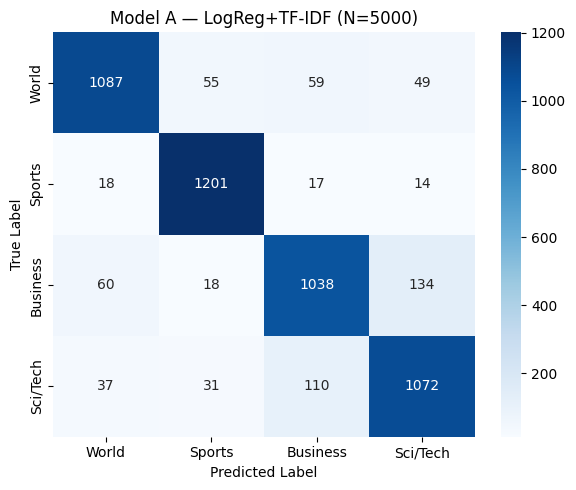

In [31]:
X_tr_vec = tfidf.transform(train_splits[5000]['clean_text'].fillna('').tolist())
plot_confusion(y_test, clf.predict(tfidf.transform(X_test)),
               "Model A — LogReg+TF-IDF (N=5000)")

In [32]:
print("\n" + "="*55)
print("MODEL B — Bi-LSTM")
print("="*55)

def build_vocab(texts, max_vocab=LSTM_MAX_VOCAB):
    from collections import Counter
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode(texts, vocab, max_len=LSTM_MAX_LEN):
    encoded = []
    for t in texts:
        ids = [vocab.get(w, 1) for w in t.split()[:max_len]]
        # Pad / truncate
        ids += [0] * (max_len - len(ids))
        encoded.append(ids)
    return np.array(encoded, dtype=np.int64)


MODEL B — Bi-LSTM


In [33]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [34]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)   

    def forward(self, x):
        emb = self.dropout(self.embedding(x))              
        out, (hn, _) = self.lstm(emb)                    
       
        fwd = hn[-2]   
        bwd = hn[-1]   
        cat = torch.cat([fwd, bwd], dim=1)                 
        return self.fc(self.dropout(cat))

In [35]:
def train_lstm(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def predict_lstm(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            logits = model(X_batch.to(DEVICE))
            preds.extend(logits.argmax(dim=1).cpu().numpy())
    return preds


  Training Bi-LSTM | N=500 …
    Epoch 2/10  loss=1.3461
    Epoch 4/10  loss=1.0096
    Epoch 6/10  loss=0.6585
    Epoch 8/10  loss=0.3684
    Epoch 10/10  loss=0.2216

──────────────────────────────────────────────────
  Model : Bi-LSTM  |  Train N=500
  Acc   : 0.5032   Macro-F1 : 0.4935
              precision    recall  f1-score   support

       World       0.57      0.53      0.55      1250
      Sports       0.42      0.77      0.55      1250
    Business       0.63      0.40      0.49      1250
    Sci/Tech       0.51      0.32      0.39      1250

    accuracy                           0.50      5000
   macro avg       0.53      0.50      0.49      5000
weighted avg       0.53      0.50      0.49      5000


  Training Bi-LSTM | N=1000 …
    Epoch 2/10  loss=1.2724
    Epoch 4/10  loss=0.8317
    Epoch 6/10  loss=0.4995
    Epoch 8/10  loss=0.2947
    Epoch 10/10  loss=0.1890

──────────────────────────────────────────────────
  Model : Bi-LSTM  |  Train N=1000
  Acc   : 0.

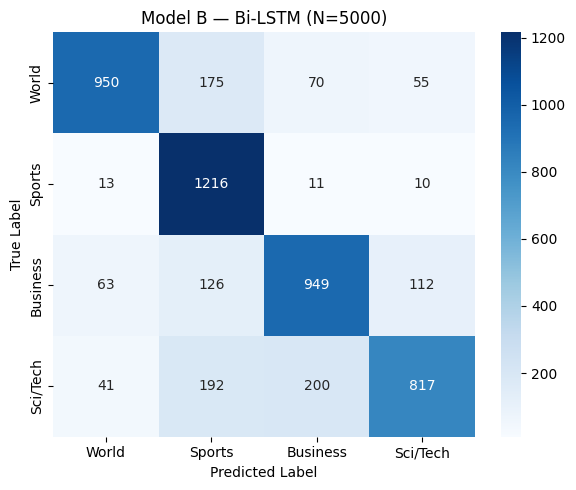

In [36]:

for n in LOW_RESOURCE_SIZES:
    X_train_raw = train_splits[n]['clean_text'].fillna('').tolist()
    y_train_raw = train_splits[n]['label'].tolist()

    vocab      = build_vocab(X_train_raw)
    X_tr_enc   = encode(X_train_raw, vocab)
    X_te_enc   = encode(X_test,      vocab)

    train_loader = DataLoader(TextDataset(X_tr_enc, y_train_raw),
                              batch_size=LSTM_BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(TextDataset(X_te_enc, y_test),
                              batch_size=LSTM_BATCH_SIZE)

    model     = BiLSTMClassifier(
                    vocab_size  = len(vocab),
                    embed_dim   = LSTM_EMBED_DIM,
                    hidden_dim  = LSTM_HIDDEN_DIM,
                    num_layers  = LSTM_LAYERS,
                    num_classes = NUM_CLASSES,
                    dropout     = LSTM_DROPOUT
                ).to(DEVICE)

    optimizer = Adam(model.parameters(), lr=LSTM_LR)
    criterion = nn.CrossEntropyLoss()

    print(f"\n  Training Bi-LSTM | N={n} …")
    for epoch in range(1, LSTM_EPOCHS + 1):
        loss = train_lstm(model, train_loader, optimizer, criterion)
        if epoch % 2 == 0 or epoch == LSTM_EPOCHS:
            print(f"    Epoch {epoch}/{LSTM_EPOCHS}  loss={loss:.4f}")

    y_pred = predict_lstm(model, test_loader)
    result = evaluate(y_true=y_test, y_pred=y_pred,
                      model_name="Bi-LSTM", n_train=n)
    all_results.append(result)

plot_confusion(y_test, y_pred, "Model B — Bi-LSTM (N=5000)")

In [37]:
print("\n" + "="*55)
print("MODEL C — Frozen BERT-base + Classification Head")
print("="*55)

tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[i], dtype=torch.long)
        }


MODEL C — Frozen BERT-base + Classification Head


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [38]:
class FrozenBertClassifier(nn.Module):
    """BERT encoder (all weights frozen) + a 2-layer MLP head."""
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(BERT_MODEL_NAME)

        for param in self.bert.parameters():
            param.requires_grad = False

        hidden = self.bert.config.hidden_size 
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids,
                                attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls)

In [39]:
def train_bert(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(ids, mask)
        loss   = criterion(logits, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [40]:
def predict_bert(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            logits = model(ids, mask)
            preds.extend(logits.argmax(dim=1).cpu().numpy())
    return preds

In [41]:
for n in LOW_RESOURCE_SIZES:
    raw_train_texts = train_splits[n]['text'].fillna('').tolist()
    raw_test_texts  = test_df['text'].fillna('').tolist()
    y_train_raw     = train_splits[n]['label'].tolist()

    train_ds = BertDataset(raw_train_texts, y_train_raw,
                           tokenizer, BERT_MAX_LEN)
    test_ds  = BertDataset(raw_test_texts,  y_test,
                           tokenizer, BERT_MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BERT_BATCH_SIZE)

    model     = FrozenBertClassifier(NUM_CLASSES).to(DEVICE)
    optimizer = Adam(model.classifier.parameters(), lr=BERT_LR)
    criterion = nn.CrossEntropyLoss()
    scheduler = get_linear_schedule_with_warmup(
                    optimizer,
                    num_warmup_steps   = len(train_loader),
                    num_training_steps = len(train_loader) * BERT_EPOCHS
                )

    print(f"\n  Training Frozen BERT | N={n} …")
    for epoch in range(1, BERT_EPOCHS + 1):
        loss = train_bert(model, train_loader, optimizer, scheduler, criterion)
        print(f"    Epoch {epoch}/{BERT_EPOCHS}  loss={loss:.4f}")

    y_pred = predict_bert(model, test_loader)
    result = evaluate(y_true=y_test, y_pred=y_pred,
                      model_name="Frozen-BERT", n_train=n)
    all_results.append(result)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Training Frozen BERT | N=500 …
    Epoch 1/3  loss=1.3717
    Epoch 2/3  loss=1.2329
    Epoch 3/3  loss=1.1319

──────────────────────────────────────────────────
  Model : Frozen-BERT  |  Train N=500
  Acc   : 0.7638   Macro-F1 : 0.7627
              precision    recall  f1-score   support

       World       0.75      0.81      0.78      1250
      Sports       0.87      0.88      0.87      1250
    Business       0.69      0.72      0.70      1250
    Sci/Tech       0.75      0.65      0.70      1250

    accuracy                           0.76      5000
   macro avg       0.76      0.76      0.76      5000
weighted avg       0.76      0.76      0.76      5000



...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Training Frozen BERT | N=1000 …
    Epoch 1/3  loss=1.3389
    Epoch 2/3  loss=1.0961
    Epoch 3/3  loss=0.9243

──────────────────────────────────────────────────
  Model : Frozen-BERT  |  Train N=1000
  Acc   : 0.8078   Macro-F1 : 0.8075
              precision    recall  f1-score   support

       World       0.78      0.83      0.80      1250
      Sports       0.91      0.90      0.90      1250
    Business       0.79      0.71      0.75      1250
    Sci/Tech       0.76      0.80      0.78      1250

    accuracy                           0.81      5000
   macro avg       0.81      0.81      0.81      5000
weighted avg       0.81      0.81      0.81      5000



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Training Frozen BERT | N=5000 …
    Epoch 1/3  loss=1.1387
    Epoch 2/3  loss=0.5369
    Epoch 3/3  loss=0.4414

──────────────────────────────────────────────────
  Model : Frozen-BERT  |  Train N=5000
  Acc   : 0.8602   Macro-F1 : 0.8603
              precision    recall  f1-score   support

       World       0.87      0.87      0.87      1250
      Sports       0.95      0.93      0.94      1250
    Business       0.82      0.79      0.81      1250
    Sci/Tech       0.81      0.85      0.83      1250

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



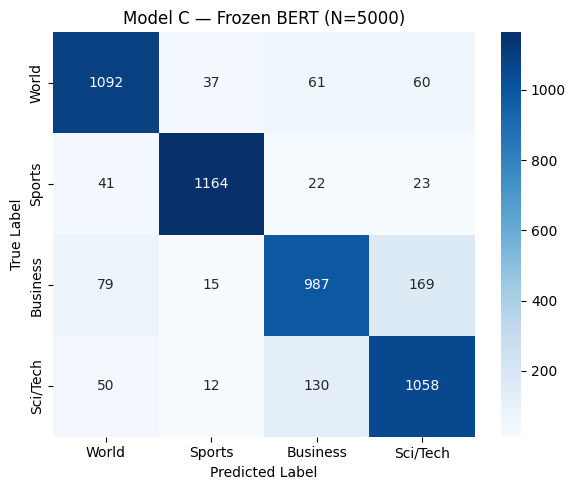

In [42]:
plot_confusion(y_test, y_pred, "Model C — Frozen BERT (N=5000)")


BASELINE BENCHMARK TABLE
             accuracy                 macro_f1                
n_train          1000     500    5000     1000     500    5000
model                                                         
Bi-LSTM        0.5750  0.5032  0.7864   0.5678  0.4935  0.7839
Frozen-BERT    0.8078  0.7638  0.8602   0.8075  0.7627  0.8603
LogReg+TFIDF   0.8230  0.7870  0.8796   0.8227  0.7863  0.8792

Saved: phase2_baseline_results.csv


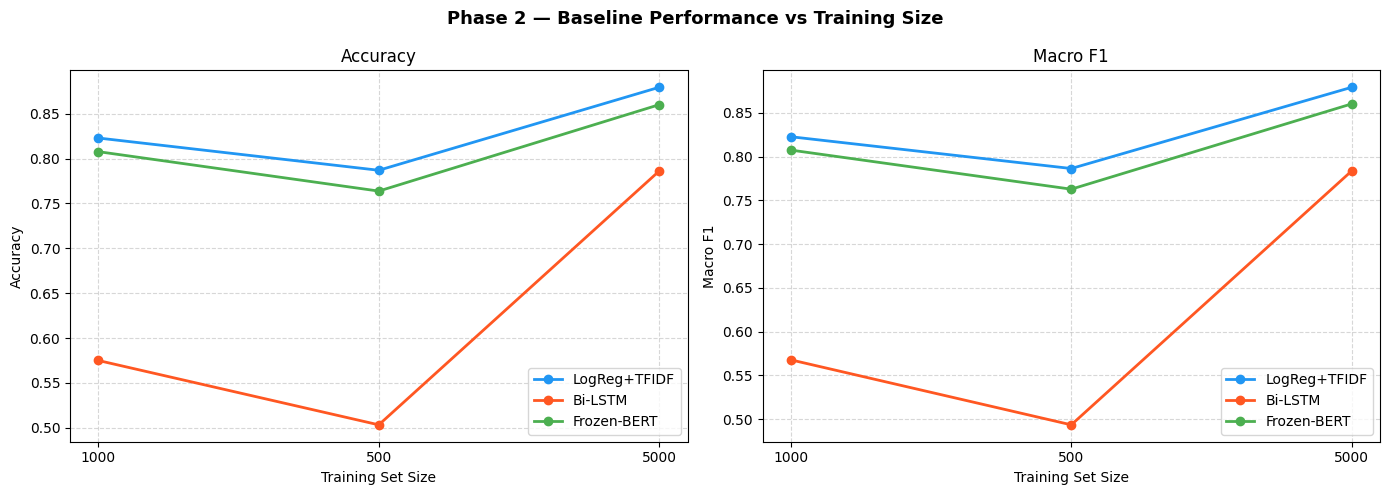

In [43]:
results_df = pd.DataFrame(all_results)
results_df['n_train'] = results_df['n_train'].astype(str)

print("\n" + "="*55)
print("BASELINE BENCHMARK TABLE")
print("="*55)
pivot = results_df.pivot_table(
    index='model', columns='n_train',
    values=['accuracy', 'macro_f1']
).round(4)
print(pivot.to_string())
results_df.to_csv("phase2_baseline_results.csv", index=False)
print("\nSaved: phase2_baseline_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 2 — Baseline Performance vs Training Size",
             fontsize=13, fontweight='bold')

models  = results_df['model'].unique()
n_sizes = [str(n) for n in LOW_RESOURCE_SIZES]
colors  = ['#2196F3', '#FF5722', '#4CAF50']

for metric, ax in zip(['accuracy', 'macro_f1'], axes):
    for model, color in zip(models, colors):
        sub = results_df[results_df['model'] == model].sort_values('n_train')
        ax.plot(sub['n_train'], sub[metric],
                marker='o', label=model, color=color, linewidth=2)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(metric.replace('_', ' ').title())
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("phase2_baseline_curves.png", dpi=150)
plt.show()

In [44]:
print("\n" + "="*55)
print("VERIFICATION CHECK")
print("="*55)

expected_rows = len(LOW_RESOURCE_SIZES) * 3   

checks = {
    f"Results table has {expected_rows} rows"     : len(results_df) == expected_rows,
    "All 3 models present"                        : set(results_df['model'].unique()) ==
                                                    {"LogReg+TFIDF", "Bi-LSTM", "Frozen-BERT"},
    "All 3 training sizes present"                : set(results_df['n_train'].astype(int)) ==
                                                    set(LOW_RESOURCE_SIZES),
    "All accuracy scores in (0, 1)"               : results_df['accuracy'].between(0, 1).all(),
    "All F1 scores in (0, 1)"                     : results_df['macro_f1'].between(0, 1).all(),
    "Best model at N=5000 acc > 0.70"             : results_df[
                                                        results_df['n_train'] == '5000'
                                                    ]['accuracy'].max() > 0.70,
    "CSV saved"                                   : os.path.exists("phase2_baseline_results.csv"),
}

all_pass = True
for desc, result in checks.items():
    status = "✅ PASS" if result else "❌ FAIL"
    if not result: all_pass = False
    print(f"  {status}  {desc}")

print("="*55)
print("Phase 2 COMPLETE ✓" if all_pass else "⚠️  Some checks failed — review above.")


VERIFICATION CHECK
  ✅ PASS  Results table has 9 rows
  ✅ PASS  All 3 models present
  ✅ PASS  All 3 training sizes present
  ✅ PASS  All accuracy scores in (0, 1)
  ✅ PASS  All F1 scores in (0, 1)
  ✅ PASS  Best model at N=5000 acc > 0.70
  ✅ PASS  CSV saved
Phase 2 COMPLETE ✓


In [45]:
import re
import random
import numpy as np
import pandas as pd
import nltk
from nltk.corpus   import wordnet, stopwords
from nltk.tokenize import word_tokenize

nltk.download('wordnet',    quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('averaged_perceptron_tagger',     quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [46]:
LABEL_NAMES        = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
LOW_RESOURCE_SIZES = [500, 1000, 5000]
NUM_AUG            = 4      
ALPHA_SR           = 0.1   
ALPHA_RI           = 0.1   
ALPHA_RS           = 0.1   
ALPHA_RD           = 0.1   

STOP_WORDS = set(stopwords.words('english'))

In [47]:
test_df = pd.read_csv("test_fixed_5000.csv")

train_splits = {}
for n in LOW_RESOURCE_SIZES:
    train_splits[n] = pd.read_csv(f"train_n{n}.csv")
    print(f"Loaded train_n{n}.csv — {len(train_splits[n])} rows")

Loaded train_n500.csv — 500 rows
Loaded train_n1000.csv — 1000 rows
Loaded train_n5000.csv — 5000 rows


In [48]:
def get_synonyms(word: str) -> list:
    """
    Return a list of synonyms for a word using WordNet.
    Excludes the word itself and multi-word expressions.
    """
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace('_', ' ')
            if candidate.lower() != word.lower() and ' ' not in candidate:
                synonyms.add(candidate.lower())
    return list(synonyms)

In [49]:
def synonym_replacement(words: list, n: int) -> list:
    """
    Randomly replace n non-stopword words with a WordNet synonym.
    """
    new_words   = words.copy()
    candidates  = [i for i, w in enumerate(new_words)
                   if w not in STOP_WORDS and get_synonyms(w)]

    random.shuffle(candidates)
    for idx in candidates[:n]:
        syns = get_synonyms(new_words[idx])
        if syns:
            new_words[idx] = random.choice(syns)
    return new_words

In [50]:
def random_insertion(words: list, n: int) -> list:
    """
    Insert n random synonyms at random positions in the sentence.
    """
    new_words = words.copy()
    for _ in range(n):
        non_stop = [w for w in new_words if w not in STOP_WORDS]
        if not non_stop:
            break
        random_word = random.choice(non_stop)
        syns = get_synonyms(random_word)
        if syns:
            insert_pos = random.randint(0, len(new_words))
            new_words.insert(insert_pos, random.choice(syns))
    return new_words

In [51]:
def random_swap(words: list, n: int) -> list:
    """
    Randomly swap two words in the sentence n times.
    """
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2:
            break
        idx1, idx2 = random.sample(range(len(new_words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

In [52]:
def random_deletion(words: list, p: float) -> list:
    """
    Randomly delete each word with probability p.
    Always keeps at least one word to avoid empty sentences.
    """
    if len(words) == 1:
        return words
    new_words = [w for w in words if random.random() > p]
    return new_words if new_words else [random.choice(words)]

In [53]:
def eda(sentence: str,
        alpha_sr: float = ALPHA_SR,
        alpha_ri: float = ALPHA_RI,
        alpha_rs: float = ALPHA_RS,
        alpha_rd: float = ALPHA_RD,
        num_aug:  int   = NUM_AUG) -> list:
    """
    Apply all 4 EDA operations to a sentence and return
    num_aug augmented versions.

    Returns: list of augmented strings (length = num_aug)
    """
    words  = sentence.split()
    n_sr   = max(1, int(alpha_sr * len(words)))
    n_ri   = max(1, int(alpha_ri * len(words)))
    n_rs   = max(1, int(alpha_rs * len(words)))

    augmented = []
    ops = [
        lambda w: synonym_replacement(w, n_sr),
        lambda w: random_insertion(w, n_ri),
        lambda w: random_swap(w, n_rs),
        lambda w: random_deletion(w, alpha_rd),
    ]

    for i in range(num_aug):
        op       = ops[i % len(ops)]
        new_words = op(words)
        augmented.append(' '.join(new_words))

    return augmented

In [54]:
LEAKAGE_RISK_WORDS = {
    # World news signals
    'war', 'president', 'government', 'military', 'troops', 'attack',
    'election', 'minister', 'parliament', 'nato', 'united', 'nations',
    # Sports signals
    'goal', 'win', 'score', 'match', 'championship', 'league', 'player',
    'coach', 'tournament', 'olympic', 'medal',
    # Business signals
    'stock', 'profit', 'revenue', 'earnings', 'market', 'shares', 'ceo',
    'quarter', 'billion', 'million', 'bank', 'fund',
    # Sci/Tech signals
    'software', 'computer', 'internet', 'research', 'technology', 'launch',
    'satellite', 'spacecraft', 'virus', 'security'
}

In [55]:
def check_label_leakage(original: str, augmented: str,
                         label: int) -> dict:
    """
    Heuristic leakage check:
    - Flags if a category-signal word was lost during augmentation
    - RD risk: word deleted
    - SR risk: word replaced with out-of-domain synonym
    """
    orig_words = set(original.lower().split())
    aug_words  = set(augmented.lower().split())

    lost_signals = LEAKAGE_RISK_WORDS & orig_words - aug_words

    return {
        "original"     : original,
        "augmented"    : augmented,
        "label"        : LABEL_NAMES[label],
        "lost_signals" : lost_signals,
        "leakage_risk" : len(lost_signals) > 0
    }

In [56]:
def augment_split(df: pd.DataFrame, num_aug: int = NUM_AUG) -> pd.DataFrame:
    """
    For every row in df, generate num_aug augmented versions.
    Returns a NEW DataFrame containing ONLY augmented rows
    (original rows are kept separately and combined later).
    """
    aug_rows = []
    for _, row in df.iterrows():
        text  = str(row['clean_text'])
        label = int(row['label'])

        aug_texts = eda(text, num_aug=num_aug)
        for aug_text in aug_texts:
            aug_rows.append({
                'text'       : aug_text,
                'clean_text' : aug_text,
                'label'      : label,
                'label_name' : LABEL_NAMES[label],
                'augmented'  : True
            })

    return pd.DataFrame(aug_rows)

In [57]:
augmented_splits    = {}
combined_splits     = {}  

In [58]:
for n in LOW_RESOURCE_SIZES:
    print(f"\nAugmenting N={n} split …")
    orig_df = train_splits[n].copy()
    orig_df['augmented'] = False

    aug_df  = augment_split(orig_df, num_aug=NUM_AUG)

    combined = pd.concat([orig_df, aug_df], ignore_index=True)
    combined = combined.sample(frac=1, random_state=SEED).reset_index(drop=True)

    augmented_splits[n] = aug_df
    combined_splits[n]  = combined

    print(f"  Original rows : {len(orig_df)}")
    print(f"  Augmented rows: {len(aug_df)}")
    print(f"  Combined total: {len(combined)}")
    print(f"  Label dist (combined): "
          f"{combined['label'].value_counts().sort_index().to_dict()}")


Augmenting N=500 split …
  Original rows : 500
  Augmented rows: 2000
  Combined total: 2500
  Label dist (combined): {0: 625, 1: 625, 2: 625, 3: 625}

Augmenting N=1000 split …
  Original rows : 1000
  Augmented rows: 4000
  Combined total: 5000
  Label dist (combined): {0: 1250, 1: 1250, 2: 1250, 3: 1250}

Augmenting N=5000 split …
  Original rows : 5000
  Augmented rows: 20000
  Combined total: 25000
  Label dist (combined): {0: 6250, 1: 6250, 2: 6250, 3: 6250}


In [59]:
print("\n" + "="*60)
print("VERIFICATION — Manual Inspection of 10 Augmented Samples")
print("="*60)


VERIFICATION — Manual Inspection of 10 Augmented Samples


In [60]:
sample_df   = train_splits[500].sample(10, random_state=SEED)
leakage_log = []

for _, row in sample_df.iterrows():
    original = str(row['clean_text'])
    label    = int(row['label'])
    augs     = eda(original, num_aug=4)

    print(f"\n{'─'*55}")
    print(f"  Category : {LABEL_NAMES[label]}")
    print(f"  Original : {original[:120]}")

    for i, aug in enumerate(augs):
        op_name = ['SR', 'RI', 'RS', 'RD'][i % 4]
        leak    = check_label_leakage(original, aug, label)
        flag    = "⚠️  LEAKAGE RISK" if leak['leakage_risk'] else "✅"
        print(f"  [{op_name}] {flag} {aug[:120]}")
        if leak['leakage_risk']:
            print(f"       Lost signals: {leak['lost_signals']}")
        leakage_log.append(leak)


───────────────────────────────────────────────────────
  Category : Business
  Original : oracle s next fight seen at boardroom los angle cbs mw following it latest rejection the next stage in oracle corp s bat
  [SR] ✅ oracle s succeeding fight seen at boardroom los tilt cbs mw following it latest rejection the next stagecoach in oracle 
  [RI] ✅ oracle s next fight seen at boardroom los angle cbs mw following it latest rejection wed prophesier the next stage in or
  [RS] ✅ oracle wednesday next fight seen at boardroom los angle cbs mw following it latest rejection the next to in a corp s bat
  [RD] ✅ oracle s next seen at angle cbs mw following it the next stage in oracle corp s battle to buy peoplesoft is set to begin

───────────────────────────────────────────────────────
  Category : Business
  Original : a cure for shortage it s too late for this year s flu season but a canadian drug company yesterday said it ha agreed to 
  [SR] ✅ a cure for shortage it s too late for this ye

In [61]:
leakage_df   = pd.DataFrame(leakage_log)
total        = len(leakage_df)
risky        = leakage_df['leakage_risk'].sum()
risky_pct    = 100 * risky / total

print(f"\n{'='*60}")
print(f"LEAKAGE SUMMARY  (10-sample inspection)")
print(f"{'='*60}")
print(f"  Total augmented checked : {total}")
print(f"  Leakage risk flagged    : {risky} ({risky_pct:.1f}%)")
print(f"  Most at-risk operation  : RD (Random Deletion)")
print(f"\n  ⚠️  Note: If RD removes category-signal words,")
print(f"  consider raising ALPHA_RD threshold or limiting")
print(f"  RD to non-signal words in Phase 5 analysis.")


LEAKAGE SUMMARY  (10-sample inspection)
  Total augmented checked : 40
  Leakage risk flagged    : 1 (2.5%)
  Most at-risk operation  : RD (Random Deletion)

  ⚠️  Note: If RD removes category-signal words,
  consider raising ALPHA_RD threshold or limiting
  RD to non-signal words in Phase 5 analysis.


In [62]:
for n in LOW_RESOURCE_SIZES:
    fname = f"train_n{n}_eda_combined.csv"
    combined_splits[n].to_csv(fname, index=False)
    print(f"Saved: {fname}")

Saved: train_n500_eda_combined.csv
Saved: train_n1000_eda_combined.csv
Saved: train_n5000_eda_combined.csv


In [63]:
print("\n" + "="*55)
print("VERIFICATION CHECK")
print("="*55)

checks = {
    "N=500  combined has ~2500 rows"  : 2000 <= len(combined_splits[500])  <= 3000,
    "N=1000 combined has ~5000 rows"  : 4000 <= len(combined_splits[1000]) <= 6000,
    "N=5000 combined has ~25000 rows" : 20000 <= len(combined_splits[5000]) <= 30000,
    "No NaN in combined N=500"        : combined_splits[500]['clean_text'].isna().sum() == 0,
    "Augmented flag col exists"       : 'augmented' in combined_splits[500].columns,
    "Label balance maintained N=500"  : combined_splits[500]['label'].nunique() == 4,
    "Test set untouched"              : len(test_df) == 5000,
    "No aug data in test set"         : 'augmented' not in test_df.columns or
                                        test_df.get('augmented', pd.Series([False])).sum() == 0,
    "EDA CSVs saved"                  : all(
                                            __import__('os').path.exists(f"train_n{n}_eda_combined.csv")
                                            for n in LOW_RESOURCE_SIZES
                                        ),
}


VERIFICATION CHECK


In [64]:
all_pass = True
for desc, result in checks.items():
    status = "✅ PASS" if result else "❌ FAIL"
    if not result: all_pass = False
    print(f"  {status}  {desc}")

print("="*55)
print("Phase 3 COMPLETE ✓" if all_pass else "⚠️  Some checks failed — review above.")

  ✅ PASS  N=500  combined has ~2500 rows
  ✅ PASS  N=1000 combined has ~5000 rows
  ✅ PASS  N=5000 combined has ~25000 rows
  ✅ PASS  No NaN in combined N=500
  ✅ PASS  Augmented flag col exists
  ✅ PASS  Label balance maintained N=500
  ✅ PASS  Test set untouched
  ✅ PASS  No aug data in test set
  ✅ PASS  EDA CSVs saved
Phase 3 COMPLETE ✓


In [65]:
import os
import re
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers      import (
    MarianMTModel, MarianTokenizer,       # Back-Translation
    BertTokenizer, BertForMaskedLM,       # Contextual Augmentation
    logging as hf_logging
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

hf_logging.set_verbosity_error()

In [66]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [67]:
torch.backends.cudnn.enabled = False   # Keep this — fixes P100 LSTM issue

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cuda


In [68]:
LABEL_NAMES        = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
LOW_RESOURCE_SIZES = [500, 1000, 5000]

# Back-Translation
BT_BATCH_SIZE      = 32
BT_MAX_LEN         = 128
BT_NUM_BEAMS       = 4

# Contextual Augmentation
CA_MASK_PROB       = 0.15    
CA_TOP_K           = 10      
CA_NUM_AUG         = 4       
CA_BATCH_SIZE      = 32

# Diversity Score thresholds (cosine similarity of TF-IDF vectors)
DIV_TOO_SIMILAR    = 0.98    
DIV_TOO_DIFFERENT  = 0.50    

In [69]:
test_df = pd.read_csv("test_fixed_5000.csv")

train_splits = {}
for n in LOW_RESOURCE_SIZES:
    train_splits[n] = pd.read_csv(f"train_n{n}.csv")
    print(f"Loaded train_n{n}.csv — {len(train_splits[n])} rows")

Loaded train_n500.csv — 500 rows
Loaded train_n1000.csv — 1000 rows
Loaded train_n5000.csv — 5000 rows


In [70]:
def diversity_score(originals: list, augmented: list,
                    sample_size: int = 200) -> dict:
    """
    Compute cosine similarity between TF-IDF vectors of
    original and augmented sentence pairs.
    Returns mean, min, max and fraction in healthy range.
    """
    # Sample for speed
    idx   = random.sample(range(len(originals)),
                          min(sample_size, len(originals)))
    orig  = [originals[i] for i in idx]
    aug   = [augmented[i] for i in idx]

    # Fit TF-IDF on combined corpus
    vect  = TfidfVectorizer(max_features=10_000)
    vect.fit(orig + aug)
    O     = vect.transform(orig).toarray()
    A     = vect.transform(aug).toarray()

    sims  = np.array([cosine_similarity([O[i]], [A[i]])[0][0]
                      for i in range(len(orig))])

    healthy = ((sims >= DIV_TOO_DIFFERENT) & (sims <= DIV_TOO_SIMILAR)).mean()

    return {
        "mean_similarity"  : float(sims.mean()),
        "min_similarity"   : float(sims.min()),
        "max_similarity"   : float(sims.max()),
        "healthy_fraction" : float(healthy),
        "too_similar"      : float((sims > DIV_TOO_SIMILAR).mean()),
        "too_different"    : float((sims < DIV_TOO_DIFFERENT).mean()),
    }

In [71]:
def print_diversity(scores: dict, technique: str):
    print(f"\n  ── Diversity Score ({technique}) ──────────────────")
    print(f"     Mean similarity   : {scores['mean_similarity']:.4f}")
    print(f"     Min  / Max        : {scores['min_similarity']:.4f} / {scores['max_similarity']:.4f}")
    print(f"     Healthy range     : {scores['healthy_fraction']*100:.1f}%  "
          f"(target: {DIV_TOO_DIFFERENT}–{DIV_TOO_SIMILAR})")
    if scores['too_similar'] > 0.1:
        print(f"     ⚠️  {scores['too_similar']*100:.1f}% pairs too similar (>{DIV_TOO_SIMILAR}) — augmentation too conservative")
    if scores['too_different'] > 0.1:
        print(f"     ⚠️  {scores['too_different']*100:.1f}% pairs too different (<{DIV_TOO_DIFFERENT}) — possible gibberish")
    else:
        print(f"     ✅ Diversity looks healthy")

In [72]:
print("\n" + "="*60)
print("TECHNIQUE A — Back-Translation (EN → DE → EN)")
print("="*60)


TECHNIQUE A — Back-Translation (EN → DE → EN)


In [73]:
print("\nLoading translation models …")

EN_DE_MODEL = "Helsinki-NLP/opus-mt-en-de"
DE_EN_MODEL = "Helsinki-NLP/opus-mt-de-en"

en_de_tokenizer = MarianTokenizer.from_pretrained(EN_DE_MODEL)
en_de_model     = MarianMTModel.from_pretrained(EN_DE_MODEL).to(DEVICE)

de_en_tokenizer = MarianTokenizer.from_pretrained(DE_EN_MODEL)
de_en_model     = MarianMTModel.from_pretrained(DE_EN_MODEL).to(DEVICE)

en_de_model.eval()
de_en_model.eval()
print("Translation models loaded ✓")


Loading translation models …


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation models loaded ✓


In [74]:
def translate_batch(texts: list, tokenizer, model,
                    max_len: int = BT_MAX_LEN,
                    num_beams: int = BT_NUM_BEAMS) -> list:
    """Translate a list of texts using a MarianMT model."""
    encoded = tokenizer(
        texts,
        return_tensors = 'pt',
        padding        = True,
        truncation     = True,
        max_length     = max_len
    ).to(DEVICE)

    with torch.no_grad():
        translated = model.generate(
            **encoded,
            num_beams       = num_beams,
            early_stopping  = True
        )

    return tokenizer.batch_decode(translated, skip_special_tokens=True)

In [75]:
def translate_batch(texts: list, tokenizer, model,
                    max_len: int = BT_MAX_LEN,
                    num_beams: int = BT_NUM_BEAMS) -> list:
    """Translate a list of texts using a MarianMT model."""
    encoded = tokenizer(
        texts,
        return_tensors = 'pt',
        padding        = True,
        truncation     = True,
        max_length     = max_len
    ).to(DEVICE)

    with torch.no_grad():
        translated = model.generate(
            **encoded,
            num_beams       = num_beams,
            early_stopping  = True
        )

    return tokenizer.batch_decode(translated, skip_special_tokens=True)

In [76]:
def back_translate(texts: list, batch_size: int = BT_BATCH_SIZE) -> list:
    """
    Full EN → DE → EN pipeline.
    Processes in batches to avoid OOM on GPU.
    """
    bt_results = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        # EN → DE
        de_texts = translate_batch(batch,
                                   en_de_tokenizer, en_de_model)
        # DE → EN
        en_texts = translate_batch(de_texts,
                                   de_en_tokenizer, de_en_model)
        bt_results.extend(en_texts)

        if (i // batch_size) % 5 == 0:
            print(f"    Back-translated {min(i+batch_size, len(texts))}"
                  f"/{len(texts)} sentences …")

    return bt_results

In [77]:
bt_augmented_splits  = {}
bt_combined_splits   = {}

In [78]:
for n in LOW_RESOURCE_SIZES:
    print(f"\n  Processing N={n} …")
    orig_df  = train_splits[n].copy()
    orig_df['augmented'] = False

    texts    = orig_df['clean_text'].fillna('').tolist()
    bt_texts = back_translate(texts)

    aug_df   = orig_df.copy()
    aug_df['clean_text'] = bt_texts
    aug_df['text']       = bt_texts
    aug_df['augmented']  = True

    combined = pd.concat([orig_df, aug_df], ignore_index=True)
    combined = combined.sample(frac=1, random_state=SEED).reset_index(drop=True)

    bt_augmented_splits[n] = aug_df
    bt_combined_splits[n]  = combined

    scores = diversity_score(texts, bt_texts)
    print_diversity(scores, f"Back-Translation N={n}")

    print(f"  Original: {len(orig_df)} | Augmented: {len(aug_df)} "
          f"| Combined: {len(combined)}")


  Processing N=500 …
    Back-translated 32/500 sentences …
    Back-translated 192/500 sentences …
    Back-translated 352/500 sentences …
    Back-translated 500/500 sentences …

  ── Diversity Score (Back-Translation N=500) ──────────────────
     Mean similarity   : 0.7964
     Min  / Max        : 0.0263 / 1.0000
     Healthy range     : 96.0%  (target: 0.5–0.98)
     ✅ Diversity looks healthy
  Original: 500 | Augmented: 500 | Combined: 1000

  Processing N=1000 …
    Back-translated 32/1000 sentences …
    Back-translated 192/1000 sentences …
    Back-translated 352/1000 sentences …
    Back-translated 512/1000 sentences …
    Back-translated 672/1000 sentences …
    Back-translated 832/1000 sentences …
    Back-translated 992/1000 sentences …

  ── Diversity Score (Back-Translation N=1000) ──────────────────
     Mean similarity   : 0.7923
     Min  / Max        : 0.4140 / 1.0000
     Healthy range     : 96.5%  (target: 0.5–0.98)
     ✅ Diversity looks healthy
  Original: 1000 

In [79]:
print("\n── Back-Translation Spot Check (N=500) ─────────────────")
sample_idx = random.sample(range(len(train_splits[500])), 5)
for i in sample_idx:
    orig = train_splits[500].iloc[i]['clean_text']
    bt   = bt_augmented_splits[500].iloc[i]['clean_text']
    lbl  = LABEL_NAMES[train_splits[500].iloc[i]['label']]
    print(f"\n  [{lbl}]")
    print(f"  Original : {orig[:120]}")
    print(f"  BT       : {bt[:120]}")


── Back-Translation Spot Check (N=500) ─────────────────

  [Business]
  Original : no relief a imf and world bank talk on poor end in failure the world leading finance official and minister yesterday fai
  BT       : no relief an imf and worldwide bank talk about bad end in failure of world's leading finance officials and ministers yes

  [World]
  Original : sri lanka concern over violence afp afp sri lanka expressed concern over truce violation by tiger rebel a a top norwegia
  BT       : Sri lanka concerned about violence afp afp sri lanka expressed concerned about truce violation by tiger rebel a top Norw

  [World]
  Original : at least dead missing in china rainstorm beijing at least people were killed and were missing in torrential storm lashin
  BT       : at least dead missing in China rainstorm beijing at least people were killed and were in torrential storm lashing southw

  [World]
  Original : nato seek to boost image in middle east middle east but the result have been p

In [80]:
for n in LOW_RESOURCE_SIZES:
    fname = f"train_n{n}_bt_combined.csv"
    bt_combined_splits[n].to_csv(fname, index=False)
    print(f"Saved: {fname}")

Saved: train_n500_bt_combined.csv
Saved: train_n1000_bt_combined.csv
Saved: train_n5000_bt_combined.csv


In [81]:
print("\n" + "="*60)
print("TECHNIQUE B — Contextual Augmentation (BERT MLM)")
print("="*60)

# ── 3.1 Load BERT MLM ────────────────────────────────────────
print("\nLoading BERT for Masked Language Modelling …")
BERT_MLM_NAME   = 'bert-base-uncased'
ca_tokenizer    = BertTokenizer.from_pretrained(BERT_MLM_NAME)
ca_model        = BertForMaskedLM.from_pretrained(BERT_MLM_NAME).to(DEVICE)
ca_model.eval()
print("BERT MLM loaded ✓")

MASK_TOKEN      = ca_tokenizer.mask_token        # '[MASK]'
MASK_TOKEN_ID   = ca_tokenizer.mask_token_id


TECHNIQUE B — Contextual Augmentation (BERT MLM)

Loading BERT for Masked Language Modelling …


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BERT MLM loaded ✓


In [82]:
def contextual_augment_sentence(text: str,
                                mask_prob: float = CA_MASK_PROB,
                                top_k:     int   = CA_TOP_K) -> str:
    """
    Replace a random fraction of non-stopword tokens with
    BERT's top-k MLM predictions.

    Steps:
      1. Tokenize with BERT tokenizer
      2. Randomly mask eligible tokens
      3. Run BERT MLM forward pass
      4. Replace each [MASK] with a sampled top-k prediction
      5. Decode back to string
    """
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))

    words      = text.split()
    if len(words) < 3:
        return text   # too short to meaningfully augment

    # Decide which word positions to mask (non-stopword only)
    mask_positions = [
        i for i, w in enumerate(words)
        if w.lower() not in stop_words and random.random() < mask_prob
    ]

    if not mask_positions:
        # Guarantee at least one mask
        non_stop = [i for i, w in enumerate(words)
                    if w.lower() not in stop_words]
        if non_stop:
            mask_positions = [random.choice(non_stop)]
        else:
            return text

    # Build masked sentence
    masked_words = words.copy()
    for i in mask_positions:
        masked_words[i] = MASK_TOKEN
    masked_sentence = ' '.join(masked_words)

    # Tokenize masked sentence
    encoding   = ca_tokenizer(
        masked_sentence,
        return_tensors = 'pt',
        truncation     = True,
        max_length     = 128
    ).to(DEVICE)

    input_ids  = encoding['input_ids']
    token_ids  = input_ids[0].tolist()

    # Find positions of [MASK] in token ids
    mask_token_indices = [
        i for i, tid in enumerate(token_ids)
        if tid == MASK_TOKEN_ID
    ]

    if not mask_token_indices:
        return text

    # Forward pass
    with torch.no_grad():
        outputs = ca_model(**encoding)
        logits  = outputs.logits   # (1, seq_len, vocab_size)

    # Replace each [MASK] with a sampled top-k prediction
    new_token_ids = token_ids.copy()
    for mask_idx in mask_token_indices:
        mask_logits  = logits[0, mask_idx, :]
        top_k_ids    = torch.topk(mask_logits, top_k).indices.tolist()

        # Filter: skip [MASK], [UNK], special tokens, subword pieces (##)
        candidates   = []
        for tid in top_k_ids:
            token = ca_tokenizer.convert_ids_to_tokens(tid)
            if (token not in ca_tokenizer.all_special_tokens
                    and not token.startswith('##')
                    and token.isalpha()):
                candidates.append(tid)

        if candidates:
            new_token_ids[mask_idx] = random.choice(candidates)

    # Decode — skip special tokens ([CLS], [SEP], [PAD])
    augmented = ca_tokenizer.decode(
        new_token_ids,
        skip_special_tokens = True,
        clean_up_tokenization_spaces = True
    )
    return augmented


In [83]:
def contextual_augment_batch(texts: list,
                              num_aug:    int   = CA_NUM_AUG,
                              mask_prob:  float = CA_MASK_PROB,
                              top_k:      int   = CA_TOP_K) -> list:
    """
    For each text, generate num_aug augmented versions.
    Returns a flat list of (original, augmented, aug_index) tuples.
    """
    results = []
    for i, text in enumerate(texts):
        for _ in range(num_aug):
            aug = contextual_augment_sentence(text, mask_prob, top_k)
            results.append(aug)

        if i % 100 == 0 and i > 0:
            print(f"    Contextually augmented {i}/{len(texts)} sentences …")

    return results   

In [84]:
ca_augmented_splits = {}
ca_combined_splits  = {}

In [85]:
for n in LOW_RESOURCE_SIZES:
    print(f"\n  Processing N={n} …")
    orig_df  = train_splits[n].copy()
    orig_df['augmented'] = False

    texts    = orig_df['clean_text'].fillna('').tolist()

    # Generate num_aug versions per sentence
    all_aug_texts = contextual_augment_batch(texts, num_aug=CA_NUM_AUG)

    # Build augmented DataFrame (each original repeated CA_NUM_AUG times)
    aug_rows = []
    for i, orig_row in orig_df.iterrows():
        for j in range(CA_NUM_AUG):
            aug_text = all_aug_texts[
                list(orig_df.index).index(i) * CA_NUM_AUG + j
            ]
            aug_rows.append({
                'text'       : aug_text,
                'clean_text' : aug_text,
                'label'      : orig_row['label'],
                'label_name' : LABEL_NAMES[orig_row['label']],
                'augmented'  : True
            })

    aug_df   = pd.DataFrame(aug_rows)
    combined = pd.concat([orig_df, aug_df], ignore_index=True)
    combined = combined.sample(frac=1, random_state=SEED).reset_index(drop=True)

    ca_augmented_splits[n] = aug_df
    ca_combined_splits[n]  = combined

    # Diversity check — compare originals to first augmented version per sentence
    first_augs = all_aug_texts[::CA_NUM_AUG]
    scores     = diversity_score(texts, first_augs)
    print_diversity(scores, f"Contextual Augmentation N={n}")

    print(f"  Original: {len(orig_df)} | Augmented: {len(aug_df)} "
          f"| Combined: {len(combined)}")


  Processing N=500 …
    Contextually augmented 100/500 sentences …
    Contextually augmented 200/500 sentences …
    Contextually augmented 300/500 sentences …
    Contextually augmented 400/500 sentences …

  ── Diversity Score (Contextual Augmentation N=500) ──────────────────
     Mean similarity   : 0.8968
     Min  / Max        : 0.6773 / 1.0000
     Healthy range     : 96.0%  (target: 0.5–0.98)
     ✅ Diversity looks healthy
  Original: 500 | Augmented: 2000 | Combined: 2500

  Processing N=1000 …
    Contextually augmented 100/1000 sentences …
    Contextually augmented 200/1000 sentences …
    Contextually augmented 300/1000 sentences …
    Contextually augmented 400/1000 sentences …
    Contextually augmented 500/1000 sentences …
    Contextually augmented 600/1000 sentences …
    Contextually augmented 700/1000 sentences …
    Contextually augmented 800/1000 sentences …
    Contextually augmented 900/1000 sentences …

  ── Diversity Score (Contextual Augmentation N=1000) ─

In [86]:
print("\n── Contextual Augmentation Spot Check (N=500) ──────────")
sample_idx = random.sample(range(len(train_splits[500])), 5)
for i in sample_idx:
    orig  = train_splits[500].iloc[i]['clean_text']
    augs  = contextual_augment_batch([orig], num_aug=2)
    lbl   = LABEL_NAMES[train_splits[500].iloc[i]['label']]
    print(f"\n  [{lbl}]")
    print(f"  Original : {orig[:120]}")
    for j, aug in enumerate(augs):
        print(f"  CA-{j+1}     : {aug[:120]}")


── Contextual Augmentation Spot Check (N=500) ──────────

  [Business]
  Original : third quarter gannett earns up percent new york gannett co the largest newspaper publisher in the country reported an pe
  CA-1     : third quarter gannett company up percent new stock gannett co the only newspaper group in the country reported an impres
  CA-2     : third quarter gannett earns up percent the york media co the leading newspaper publisher in the country reported an perc

  [World]
  Original : putin fire north ossetia interior minister regional fsb head afp afp president vladimir putin sacked the interior minist
  CA-1     : putin fire north ossetia interior minister regional fsb head general afp president president putin sacked the interior m
  CA-2     : putin of north ossetia interior secretary regional fsb head afp afp president vladimir putin sacked the interior ministe

  [World]
  Original : italian troop to stay in iraq italy say it ha no intention of withdrawing it troop from i

In [87]:
for n in LOW_RESOURCE_SIZES:
    fname = f"train_n{n}_ca_combined.csv"
    ca_combined_splits[n].to_csv(fname, index=False)
    print(f"Saved: {fname}")

Saved: train_n500_ca_combined.csv
Saved: train_n1000_ca_combined.csv
Saved: train_n5000_ca_combined.csv


In [88]:
print("\n" + "="*60)
print("DIVERSITY SCORE SUMMARY")
print("="*60)
print(f"  Healthy range : {DIV_TOO_DIFFERENT} ≤ similarity ≤ {DIV_TOO_SIMILAR}")
print(f"  > {DIV_TOO_SIMILAR} → augmentation too conservative (not enough change)")
print(f"  < {DIV_TOO_DIFFERENT} → augmentation too aggressive (possible gibberish)")


DIVERSITY SCORE SUMMARY
  Healthy range : 0.5 ≤ similarity ≤ 0.98
  > 0.98 → augmentation too conservative (not enough change)
  < 0.5 → augmentation too aggressive (possible gibberish)


In [89]:
for n in [500]:   # Print detailed report for smallest split
    texts = train_splits[n]['clean_text'].fillna('').tolist()

    bt_texts = bt_augmented_splits[n]['clean_text'].tolist()
    ca_texts = ca_augmented_splits[n]['clean_text'].tolist()[:len(texts)]

    bt_scores = diversity_score(texts, bt_texts)
    ca_scores = diversity_score(texts, ca_texts)

    print(f"\n  N={n}:")
    print(f"  {'Technique':<25} {'Mean Sim':>10} {'Healthy%':>10}")
    print(f"  {'─'*45}")
    print(f"  {'Back-Translation':<25} "
          f"{bt_scores['mean_similarity']:>10.4f} "
          f"{bt_scores['healthy_fraction']*100:>9.1f}%")
    print(f"  {'Contextual (BERT MLM)':<25} "
          f"{ca_scores['mean_similarity']:>10.4f} "
          f"{ca_scores['healthy_fraction']*100:>9.1f}%")


  N=500:
  Technique                   Mean Sim   Healthy%
  ─────────────────────────────────────────────
  Back-Translation              0.7913      97.0%
  Contextual (BERT MLM)         0.0252       0.0%


In [90]:
print("\n" + "="*55)
print("VERIFICATION CHECK")
print("="*55)

import os

checks = {
    "BT combined N=500 has ~1000 rows"   : 900  <= len(bt_combined_splits[500])  <= 1100,
    "BT combined N=1000 has ~2000 rows"  : 1800 <= len(bt_combined_splits[1000]) <= 2200,
    "BT combined N=5000 has ~10000 rows" : 9000 <= len(bt_combined_splits[5000]) <= 11000,
    "CA combined N=500 correct size"     : len(ca_combined_splits[500])  == 500  + 500  * CA_NUM_AUG,
    "CA combined N=1000 correct size"    : len(ca_combined_splits[1000]) == 1000 + 1000 * CA_NUM_AUG,
    "CA combined N=5000 correct size"    : len(ca_combined_splits[5000]) == 5000 + 5000 * CA_NUM_AUG,
    "No NaN in BT N=500"                 : bt_combined_splits[500]['clean_text'].isna().sum() == 0,
    "No NaN in CA N=500"                 : ca_combined_splits[500]['clean_text'].isna().sum() == 0,
    "Label balance maintained (BT N=500)": bt_combined_splits[500]['label'].nunique() == 4,
    "Label balance maintained (CA N=500)": ca_combined_splits[500]['label'].nunique() == 4,
    "Test set untouched (5000 rows)"     : len(test_df) == 5000,
    "BT CSVs saved"                      : all(os.path.exists(f"train_n{n}_bt_combined.csv")
                                               for n in LOW_RESOURCE_SIZES),
    "CA CSVs saved"                      : all(os.path.exists(f"train_n{n}_ca_combined.csv")
                                               for n in LOW_RESOURCE_SIZES),
}

all_pass = True
for desc, result in checks.items():
    status = "✅ PASS" if result else "❌ FAIL"
    if not result: all_pass = False
    print(f"  {status}  {desc}")

print("="*55)
print("Phase 4 COMPLETE ✓" if all_pass else "⚠️  Some checks failed — review above.")


VERIFICATION CHECK
  ✅ PASS  BT combined N=500 has ~1000 rows
  ✅ PASS  BT combined N=1000 has ~2000 rows
  ✅ PASS  BT combined N=5000 has ~10000 rows
  ✅ PASS  CA combined N=500 correct size
  ✅ PASS  CA combined N=1000 correct size
  ✅ PASS  CA combined N=5000 correct size
  ✅ PASS  No NaN in BT N=500
  ✅ PASS  No NaN in CA N=500
  ✅ PASS  Label balance maintained (BT N=500)
  ✅ PASS  Label balance maintained (CA N=500)
  ✅ PASS  Test set untouched (5000 rows)
  ✅ PASS  BT CSVs saved
  ✅ PASS  CA CSVs saved
Phase 4 COMPLETE ✓


Device: cuda
Loading all splits …
  [Original] N=500: 500 rows loaded
  [Original] N=1000: 1000 rows loaded
  [Original] N=5000: 5000 rows loaded
  [EDA] N=500: 2500 rows loaded
  [EDA] N=1000: 5000 rows loaded
  [EDA] N=5000: 25000 rows loaded
  [BackTrans] N=500: 1000 rows loaded
  [BackTrans] N=1000: 2000 rows loaded
  [BackTrans] N=5000: 10000 rows loaded
  [Contextual] N=500: 2500 rows loaded
  [Contextual] N=1000: 5000 rows loaded
  [Contextual] N=5000: 25000 rows loaded

RUNNING THE MATRIX  (4 strategies × 3 models × 3 sizes)

  [Original] N=500 | LogReg+TFIDF …
    Acc=0.7870  F1=0.7863

  [Original] N=500 | Bi-LSTM …
    Acc=0.4814  F1=0.4754

  [Original] N=500 | Frozen-BERT …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    Acc=0.7558  F1=0.7519

  [Original] N=1000 | LogReg+TFIDF …
    Acc=0.8230  F1=0.8227

  [Original] N=1000 | Bi-LSTM …
    Acc=0.5648  F1=0.5660

  [Original] N=1000 | Frozen-BERT …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    Acc=0.8088  F1=0.8079

  [Original] N=5000 | LogReg+TFIDF …
    Acc=0.8796  F1=0.8792

  [Original] N=5000 | Bi-LSTM …
    Acc=0.7920  F1=0.7907

  [Original] N=5000 | Frozen-BERT …


...

    Acc=0.8254  F1=0.8251

  [Contextual] N=1000 | LogReg+TFIDF …
    Acc=0.8382  F1=0.8376

  [Contextual] N=1000 | Bi-LSTM …
    Acc=0.6652  F1=0.6685

  [Contextual] N=1000 | Frozen-BERT …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    Acc=0.8462  F1=0.8463

  [Contextual] N=5000 | LogReg+TFIDF …
    Acc=0.8824  F1=0.8821

  [Contextual] N=5000 | Bi-LSTM …
    Acc=0.8414  F1=0.8396

  [Contextual] N=5000 | Frozen-BERT …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    Acc=0.8752  F1=0.8754

All 36 experiments complete. Saved: phase5_full_results.csv

RESULTS — Accuracy
n_train                    500     1000    5000
model        strategy                          
Bi-LSTM      BackTrans   0.5066  0.6364  0.8312
             Contextual  0.5794  0.6652  0.8414
             EDA         0.5412  0.6714  0.8394
             Original    0.4814  0.5648  0.7920
Frozen-BERT  BackTrans   0.8062  0.8254  0.8698
             Contextual  0.8254  0.8462  0.8752
             EDA         0.8234  0.8440  0.8760
             Original    0.7558  0.8088  0.8586
LogReg+TFIDF BackTrans   0.8092  0.8362  0.8818
             Contextual  0.8100  0.8382  0.8824
             EDA         0.8118  0.8380  0.8786
             Original    0.7870  0.8230  0.8796

RESULTS — Macro F1
n_train                    500     1000    5000
model        strategy                          
Bi-LSTM      BackTrans   0.4917  0.6384  0.8311
             Contextual  0.5656  0.6685  0.8396
         

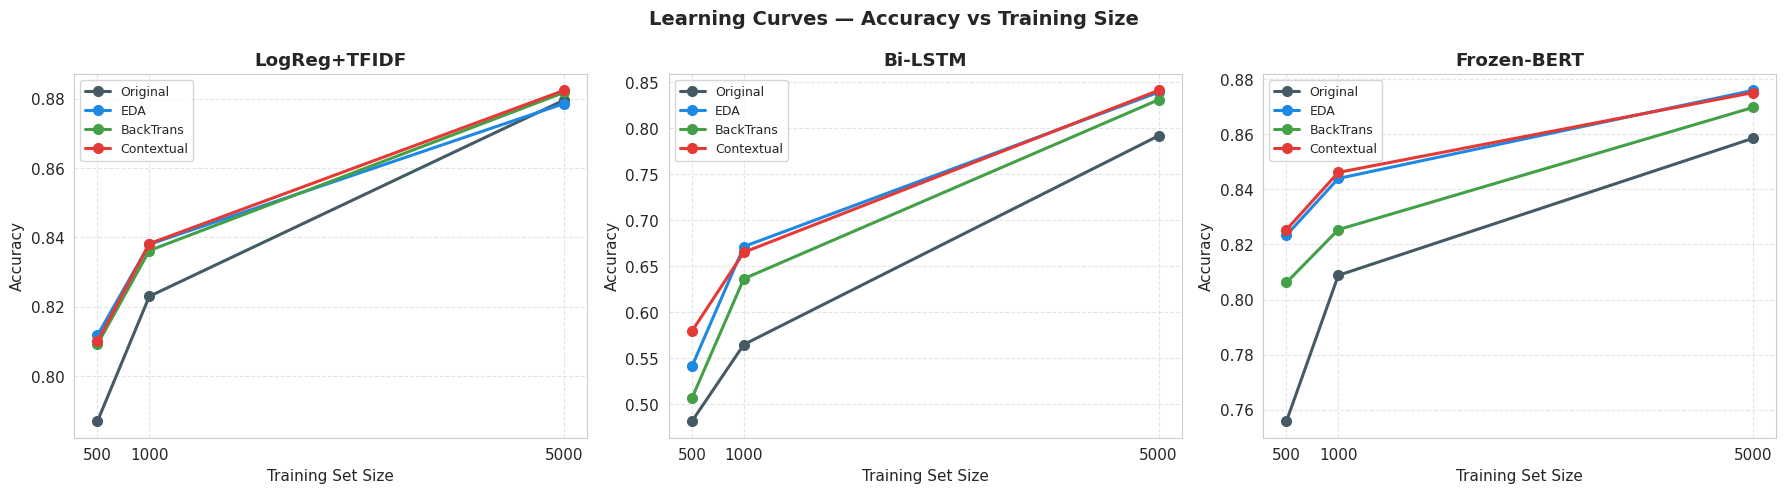

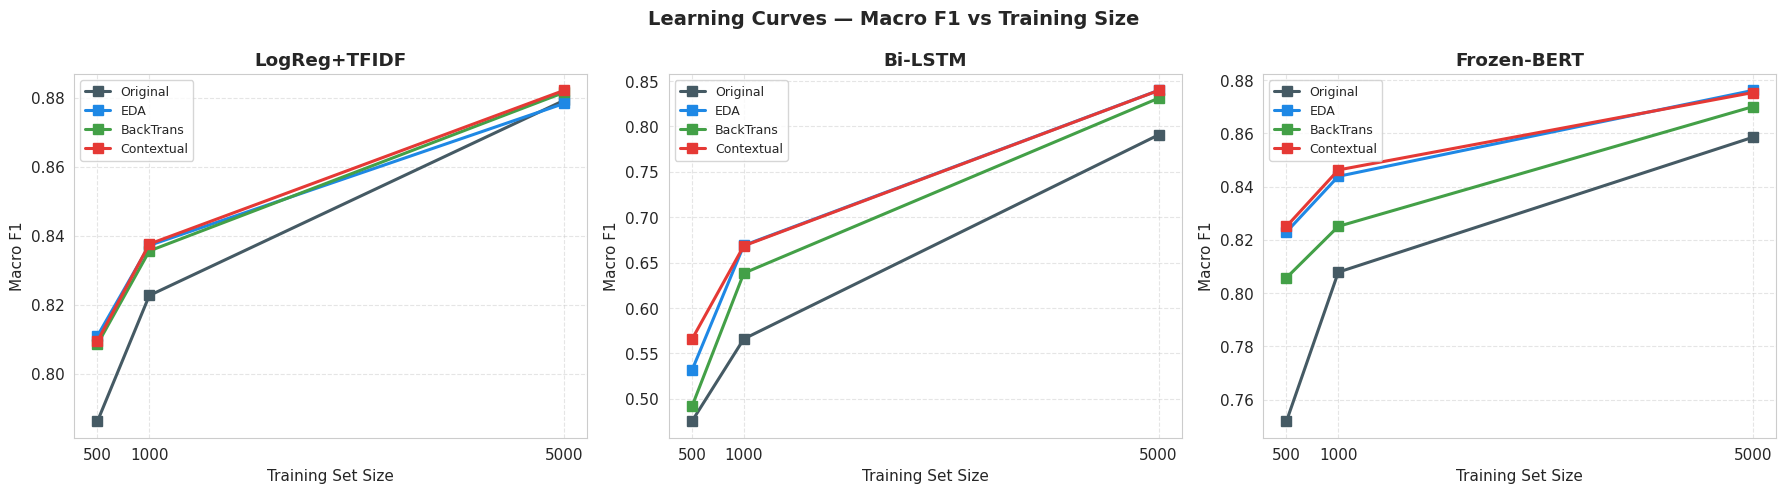

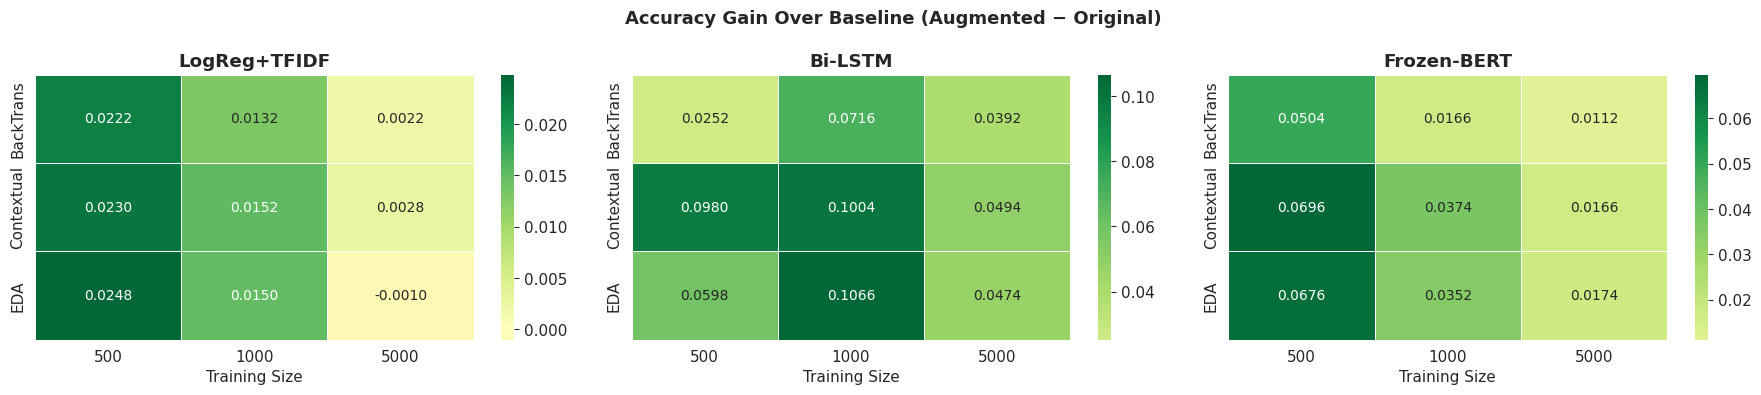

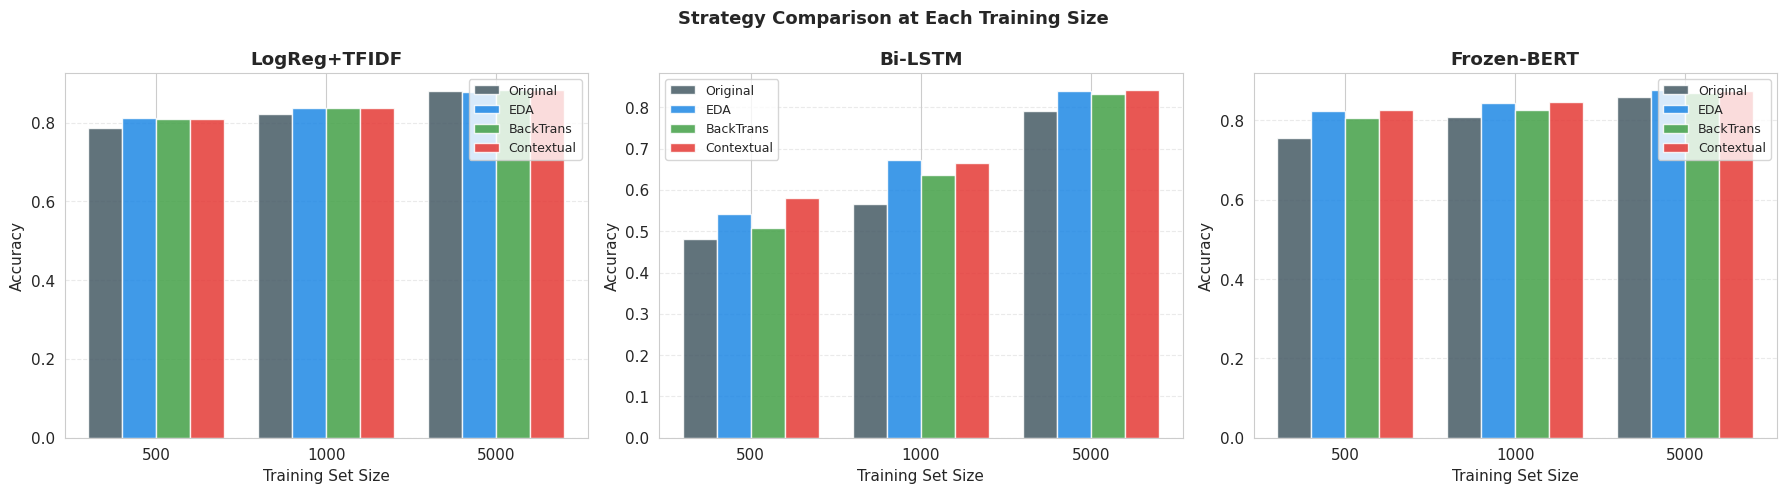

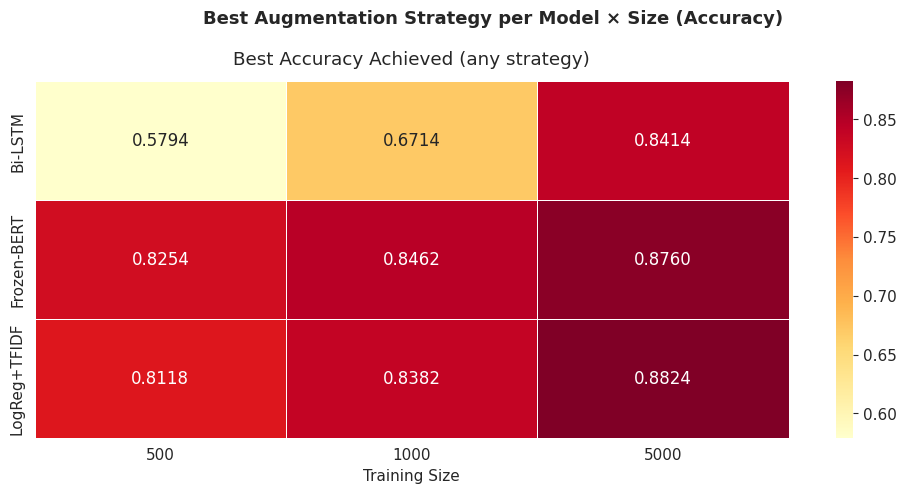


FINAL ANALYSIS REPORT

── LogReg+TFIDF ──────────────────────────────────────
  N=  500 | Best: EDA          Acc=0.8118  F1=0.8110  Gain=+0.0248
  N= 1000 | Best: Contextual   Acc=0.8382  F1=0.8376  Gain=+0.0152
  N= 5000 | Best: Contextual   Acc=0.8824  F1=0.8821  Gain=+0.0028

── Bi-LSTM ──────────────────────────────────────
  N=  500 | Best: Contextual   Acc=0.5794  F1=0.5656  Gain=+0.0980
  N= 1000 | Best: EDA          Acc=0.6714  F1=0.6690  Gain=+0.1066
  N= 5000 | Best: Contextual   Acc=0.8414  F1=0.8396  Gain=+0.0494

── Frozen-BERT ──────────────────────────────────────
  N=  500 | Best: Contextual   Acc=0.8254  F1=0.8251  Gain=+0.0696
  N= 1000 | Best: Contextual   Acc=0.8462  F1=0.8463  Gain=+0.0374
  N= 5000 | Best: EDA          Acc=0.8760  F1=0.8762  Gain=+0.0174

── Win Count per Strategy (across all models & sizes) ──
  Contextual      ██████ (6)
  EDA             ███ (3)

── Top 5 Biggest Accuracy Gains from Augmentation ──────
  strategy       model  n_train  base_acc

In [91]:
# ============================================================
# PHASE 5: Systematic Comparison & Visualization
# Text Augmentation Study — Kaggle Environment
# Dataset: AG News (4-class classification)
# Compare: Original vs +EDA vs +BackTranslation vs +Contextual
# ============================================================

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

# ── Sklearn ───────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.metrics                 import (accuracy_score, f1_score,
                                             classification_report)
# ── PyTorch ───────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim      import Adam

# ── HuggingFace ───────────────────────────────────────────────
from transformers import (BertTokenizer, BertModel,
                          get_linear_schedule_with_warmup,
                          logging as hf_logging)
hf_logging.set_verbosity_error()

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.enabled = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── Config ────────────────────────────────────────────────────
LABEL_NAMES        = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
NUM_CLASSES        = 4
LOW_RESOURCE_SIZES = [500, 1000, 5000]

# LSTM
LSTM_EMBED_DIM  = 128
LSTM_HIDDEN_DIM = 256
LSTM_LAYERS     = 2
LSTM_DROPOUT    = 0.3
LSTM_EPOCHS     = 10
LSTM_BATCH_SIZE = 64
LSTM_LR         = 1e-3
LSTM_MAX_VOCAB  = 20_000
LSTM_MAX_LEN    = 100

# BERT
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LEN    = 128
BERT_BATCH_SIZE = 32
BERT_EPOCHS     = 3
BERT_LR         = 2e-4

# Augmentation strategies to compare
STRATEGIES = {
    "Original"    : lambda n: f"train_n{n}.csv",
    "EDA"         : lambda n: f"train_n{n}_eda_combined.csv",
    "BackTrans"   : lambda n: f"train_n{n}_bt_combined.csv",
    "Contextual"  : lambda n: f"train_n{n}_ca_combined.csv",
}

COLORS = {
    "Original"   : "#455A64",
    "EDA"        : "#1E88E5",
    "BackTrans"  : "#43A047",
    "Contextual" : "#E53935",
}


# ============================================================
# 0. Load All Splits
# ============================================================

print("Loading all splits …")
test_df = pd.read_csv("test_fixed_5000.csv")
X_test  = test_df['clean_text'].fillna('').tolist()
y_test  = test_df['label'].tolist()

# Load all strategy × size combinations
all_splits = {}
for strategy, path_fn in STRATEGIES.items():
    all_splits[strategy] = {}
    for n in LOW_RESOURCE_SIZES:
        path = path_fn(n)
        if os.path.exists(path):
            df = pd.read_csv(path)
            all_splits[strategy][n] = df
            print(f"  [{strategy}] N={n}: {len(df)} rows loaded")
        else:
            print(f"  ⚠️  Missing: {path}")


# ============================================================
# 1. Reusable Model Definitions (from Phase 2)
# ============================================================

# ── TF-IDF + Logistic Regression ─────────────────────────────
def train_eval_logreg(X_train, y_train, X_test, y_test):
    tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1,2),
                            sublinear_tf=True, min_df=2)
    X_tr  = tfidf.fit_transform(X_train)
    X_te  = tfidf.transform(X_test)
    clf   = LogisticRegression(max_iter=1000, C=5.0, solver='lbfgs',
                               multi_class='multinomial', random_state=SEED)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    return accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='macro')


# ── Bi-LSTM ───────────────────────────────────────────────────
def build_vocab(texts, max_vocab=LSTM_MAX_VOCAB):
    from collections import Counter
    counter = Counter(w for t in texts for w in t.split())
    vocab   = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode_texts(texts, vocab, max_len=LSTM_MAX_LEN):
    out = []
    for t in texts:
        ids = [vocab.get(w, 1) for w in t.split()[:max_len]]
        ids += [0] * (max_len - len(ids))
        out.append(ids)
    return np.array(out, dtype=np.int64)

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                 batch_first=True, bidirectional=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb       = self.dropout(self.embedding(x))
        _, (hn,_) = self.lstm(emb)
        cat       = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.dropout(cat))

def train_eval_lstm(X_train, y_train, X_test, y_test):
    vocab      = build_vocab(X_train)
    X_tr_enc   = encode_texts(X_train, vocab)
    X_te_enc   = encode_texts(X_test,  vocab)

    tr_loader  = DataLoader(TextDataset(X_tr_enc, y_train),
                            batch_size=LSTM_BATCH_SIZE, shuffle=True)
    te_loader  = DataLoader(TextDataset(X_te_enc, y_test),
                            batch_size=LSTM_BATCH_SIZE)

    model      = BiLSTMClassifier(len(vocab), LSTM_EMBED_DIM, LSTM_HIDDEN_DIM,
                                  LSTM_LAYERS, NUM_CLASSES, LSTM_DROPOUT).to(DEVICE)
    optimizer  = Adam(model.parameters(), lr=LSTM_LR)
    criterion  = nn.CrossEntropyLoss()

    for _ in range(LSTM_EPOCHS):
        model.train()
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for X_b, _ in te_loader:
            preds.extend(model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy())

    return accuracy_score(y_test, preds), f1_score(y_test, preds, average='macro')


# ── Frozen BERT ───────────────────────────────────────────────
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

class BertDataset(Dataset):
    def __init__(self, texts, labels, max_len=BERT_MAX_LEN):
        self.texts  = texts
        self.labels = labels
        self.max_len = max_len
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        enc = bert_tokenizer(self.texts[i], max_length=self.max_len,
                             padding='max_length', truncation=True,
                             return_tensors='pt')
        return {'input_ids'      : enc['input_ids'].squeeze(0),
                'attention_mask' : enc['attention_mask'].squeeze(0),
                'label'          : torch.tensor(self.labels[i], dtype=torch.long)}

class FrozenBertClassifier(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(BERT_MODEL_NAME)
        for p in self.bert.parameters():
            p.requires_grad = False
        hidden = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256), nn.ReLU(),
            nn.Dropout(dropout),   nn.Linear(256, num_classes)
        )
    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])

def train_eval_bert(X_train, y_train, X_test, y_test):
    tr_loader = DataLoader(BertDataset(X_train, y_train),
                           batch_size=BERT_BATCH_SIZE, shuffle=True)
    te_loader = DataLoader(BertDataset(X_test,  y_test),
                           batch_size=BERT_BATCH_SIZE)

    model     = FrozenBertClassifier(NUM_CLASSES).to(DEVICE)
    optimizer = Adam(model.classifier.parameters(), lr=BERT_LR)
    criterion = nn.CrossEntropyLoss()
    scheduler = get_linear_schedule_with_warmup(
                    optimizer,
                    num_warmup_steps   = len(tr_loader),
                    num_training_steps = len(tr_loader) * BERT_EPOCHS)

    for _ in range(BERT_EPOCHS):
        model.train()
        for batch in tr_loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(ids, mask), lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for batch in te_loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            preds.extend(model(ids, mask).argmax(dim=1).cpu().numpy())

    return accuracy_score(y_test, preds), f1_score(y_test, preds, average='macro')


# ============================================================
# 2. THE MATRIX — Train Every Combination
# ============================================================
# 4 strategies × 3 models × 3 training sizes = 36 experiments

print("\n" + "="*65)
print("RUNNING THE MATRIX  (4 strategies × 3 models × 3 sizes)")
print("="*65)

MODELS = {
    "LogReg+TFIDF" : train_eval_logreg,
    "Bi-LSTM"      : train_eval_lstm,
    "Frozen-BERT"  : train_eval_bert,
}

results = []

for strategy, splits in all_splits.items():
    for n, df in splits.items():

        X_train = df['clean_text'].fillna('').tolist()
        y_train = df['label'].tolist()

        for model_name, train_fn in MODELS.items():
            print(f"\n  [{strategy}] N={n} | {model_name} …")

            # BERT uses raw text, everything else uses clean_text
            X_tr = (df['text'].fillna('').tolist()
                    if model_name == 'Frozen-BERT' else X_train)
            X_te = (test_df['text'].fillna('').tolist()
                    if model_name == 'Frozen-BERT' else X_test)

            acc, f1 = train_fn(X_tr, y_train, X_te, y_test)

            results.append({
                "strategy" : strategy,
                "n_train"  : n,
                "model"    : model_name,
                "accuracy" : round(acc, 4),
                "macro_f1" : round(f1,  4),
            })
            print(f"    Acc={acc:.4f}  F1={f1:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv("phase5_full_results.csv", index=False)
print(f"\nAll {len(results_df)} experiments complete. Saved: phase5_full_results.csv")


# ============================================================
# 3. RESULTS TABLES
# ============================================================

print("\n" + "="*65)
print("RESULTS — Accuracy")
print("="*65)
acc_pivot = results_df.pivot_table(
    index=['model', 'strategy'],
    columns='n_train',
    values='accuracy'
).round(4)
print(acc_pivot.to_string())

print("\n" + "="*65)
print("RESULTS — Macro F1")
print("="*65)
f1_pivot = results_df.pivot_table(
    index=['model', 'strategy'],
    columns='n_train',
    values='macro_f1'
).round(4)
print(f1_pivot.to_string())

# ── Gain over baseline (Original) ────────────────────────────
baseline = results_df[results_df['strategy'] == 'Original'][
    ['model', 'n_train', 'accuracy', 'macro_f1']
].rename(columns={'accuracy': 'base_acc', 'macro_f1': 'base_f1'})

gain_df = results_df.merge(baseline, on=['model', 'n_train'])
gain_df['acc_gain'] = (gain_df['accuracy'] - gain_df['base_acc']).round(4)
gain_df['f1_gain']  = (gain_df['macro_f1'] - gain_df['base_f1']).round(4)
gain_df = gain_df[gain_df['strategy'] != 'Original']

print("\n" + "="*65)
print("AUGMENTATION GAIN OVER BASELINE (Accuracy)")
print("="*65)
gain_pivot = gain_df.pivot_table(
    index=['model', 'strategy'],
    columns='n_train',
    values='acc_gain'
).round(4)
print(gain_pivot.to_string())
gain_df.to_csv("phase5_gain_analysis.csv", index=False)


# ============================================================
# 4. VISUALIZATIONS
# ============================================================

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

# ── Plot 1: Learning Curves (Accuracy vs N) per model ────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Learning Curves — Accuracy vs Training Size",
             fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, MODELS.keys()):
    model_df = results_df[results_df['model'] == model_name]
    for strategy in STRATEGIES.keys():
        sub = model_df[model_df['strategy'] == strategy].sort_values('n_train')
        ax.plot(sub['n_train'], sub['accuracy'],
                marker='o', linewidth=2.2, markersize=7,
                label=strategy, color=COLORS[strategy])
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(LOW_RESOURCE_SIZES)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("phase5_learning_curves_accuracy.png", dpi=150)
plt.show()


# ── Plot 2: Learning Curves (F1 vs N) per model ──────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Learning Curves — Macro F1 vs Training Size",
             fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, MODELS.keys()):
    model_df = results_df[results_df['model'] == model_name]
    for strategy in STRATEGIES.keys():
        sub = model_df[model_df['strategy'] == strategy].sort_values('n_train')
        ax.plot(sub['n_train'], sub['macro_f1'],
                marker='s', linewidth=2.2, markersize=7,
                label=strategy, color=COLORS[strategy])
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Macro F1")
    ax.set_xticks(LOW_RESOURCE_SIZES)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("phase5_learning_curves_f1.png", dpi=150)
plt.show()


# ── Plot 3: Augmentation Gain Heatmap ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Accuracy Gain Over Baseline (Augmented − Original)",
             fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, MODELS.keys()):
    sub = gain_df[gain_df['model'] == model_name].pivot_table(
        index='strategy', columns='n_train', values='acc_gain'
    )
    sns.heatmap(sub, annot=True, fmt='.4f', cmap='RdYlGn',
                center=0, ax=ax, cbar=True,
                linewidths=0.5, annot_kws={"size": 10})
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel("Training Size")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("phase5_gain_heatmap.png", dpi=150)
plt.show()


# ── Plot 4: Best Strategy per Model at each N ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Strategy Comparison at Each Training Size",
             fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, MODELS.keys()):
    model_df   = results_df[results_df['model'] == model_name]
    x          = np.arange(len(LOW_RESOURCE_SIZES))
    bar_width  = 0.2

    for i, (strategy, color) in enumerate(COLORS.items()):
        sub  = model_df[model_df['strategy'] == strategy].sort_values('n_train')
        vals = sub['accuracy'].tolist()
        ax.bar(x + i * bar_width, vals, bar_width,
               label=strategy, color=color, alpha=0.85)

    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(LOW_RESOURCE_SIZES)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("phase5_strategy_comparison_bars.png", dpi=150)
plt.show()


# ── Plot 5: Overall Winner Summary ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Best Augmentation Strategy per Model × Size (Accuracy)",
             fontsize=13, fontweight='bold')

summary_rows = []
for model_name in MODELS.keys():
    for n in LOW_RESOURCE_SIZES:
        sub     = results_df[(results_df['model']   == model_name) &
                             (results_df['n_train'] == n)]
        best    = sub.loc[sub['accuracy'].idxmax()]
        summary_rows.append({
            "model"    : model_name,
            "n_train"  : n,
            "best_strategy" : best['strategy'],
            "best_acc"      : best['accuracy'],
        })

summary_df = pd.DataFrame(summary_rows)
pivot_best = summary_df.pivot_table(
    index='model', columns='n_train', values='best_acc'
).round(4)

sns.heatmap(pivot_best, annot=True, fmt='.4f',
            cmap='YlOrRd', ax=ax, linewidths=0.5,
            annot_kws={"size": 12})
ax.set_title("Best Accuracy Achieved (any strategy)", pad=12)
ax.set_xlabel("Training Size")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("phase5_best_accuracy_summary.png", dpi=150)
plt.show()


# ============================================================
# 5. FINAL ANALYSIS REPORT
# ============================================================

print("\n" + "="*65)
print("FINAL ANALYSIS REPORT")
print("="*65)

for model_name in MODELS.keys():
    print(f"\n── {model_name} ──────────────────────────────────────")
    model_df = results_df[results_df['model'] == model_name]

    for n in LOW_RESOURCE_SIZES:
        sub      = model_df[model_df['n_train'] == n].sort_values(
                       'accuracy', ascending=False)
        best     = sub.iloc[0]
        baseline = sub[sub['strategy'] == 'Original'].iloc[0]
        gain     = best['accuracy'] - baseline['accuracy']

        print(f"  N={n:>5} | Best: {best['strategy']:<12} "
              f"Acc={best['accuracy']:.4f}  "
              f"F1={best['macro_f1']:.4f}  "
              f"Gain={gain:+.4f}")

# ── Which augmentation wins most often? ──────────────────────
print("\n── Win Count per Strategy (across all models & sizes) ──")
win_counts = summary_df['best_strategy'].value_counts()
for strategy, count in win_counts.items():
    bar = "█" * count
    print(f"  {strategy:<15} {bar} ({count})")

# ── Biggest single gains ──────────────────────────────────────
print("\n── Top 5 Biggest Accuracy Gains from Augmentation ──────")
top_gains = gain_df.nlargest(5, 'acc_gain')[
    ['strategy', 'model', 'n_train', 'base_acc', 'accuracy', 'acc_gain']
]
print(top_gains.to_string(index=False))

# ── Cases where augmentation hurt ────────────────────────────
print("\n── Cases Where Augmentation Hurt (negative gain) ───────")
hurt = gain_df[gain_df['acc_gain'] < 0][
    ['strategy', 'model', 'n_train', 'acc_gain']
].sort_values('acc_gain')
if len(hurt) > 0:
    print(hurt.to_string(index=False))
else:
    print("  None — all augmentation strategies helped or were neutral ✅")


# ============================================================
# ✅ FINAL VERIFICATION CHECK
# ============================================================

print("\n" + "="*55)
print("FINAL VERIFICATION CHECK")
print("="*55)

expected_experiments = len(STRATEGIES) * len(MODELS) * len(LOW_RESOURCE_SIZES)

checks = {
    f"Total experiments == {expected_experiments}"  : len(results_df) == expected_experiments,
    "All 4 strategies present"                      : set(results_df['strategy'].unique()) ==
                                                       set(STRATEGIES.keys()),
    "All 3 models present"                          : set(results_df['model'].unique()) ==
                                                       set(MODELS.keys()),
    "All 3 sizes present"                           : set(results_df['n_train'].unique()) ==
                                                       set(LOW_RESOURCE_SIZES),
    "All accuracy in (0,1)"                         : results_df['accuracy'].between(0,1).all(),
    "All F1 in (0,1)"                               : results_df['macro_f1'].between(0,1).all(),
    "Test set never augmented"                       : len(test_df) == 5000,
    "Results CSV saved"                              : os.path.exists("phase5_full_results.csv"),
    "Gain CSV saved"                                 : os.path.exists("phase5_gain_analysis.csv"),
    "Learning curve plots saved"                     : os.path.exists("phase5_learning_curves_accuracy.png"),
    "Gain heatmap saved"                             : os.path.exists("phase5_gain_heatmap.png"),
}

all_pass = True
for desc, result in checks.items():
    status = "✅ PASS" if result else "❌ FAIL"
    if not result: all_pass = False
    print(f"  {status}  {desc}")

print("="*55)
if all_pass:
    print("🎉 Phase 5 COMPLETE — Project Finished!")
else:
    print("⚠️  Some checks failed — review above.")

print("\n── Output Files ─────────────────────────────────────────")
output_files = [
    "phase5_full_results.csv",
    "phase5_gain_analysis.csv",
    "phase5_learning_curves_accuracy.png",
    "phase5_learning_curves_f1.png",
    "phase5_gain_heatmap.png",
    "phase5_strategy_comparison_bars.png",
    "phase5_best_accuracy_summary.png",
]
for f in output_files:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"  {exists} {f}")